# Overview Map for Differently Set Up Hurricane-Centric Domains

This creates a visual overview for the different grid segments.


Using levante python kernel "1 Python 3" (can be recreated from `../environment-standard.yml`)

In the following:
- four different configurations are read
- for each, the grids of the hurricane segments are input
- grid outlines are plot with different colors 

## Libs

In [1]:
%matplotlib inline

import os, sys, glob
import pylab as plt
import numpy as np
import string
import seaborn as sns
sns.set_context('talk')


import xarray as xr
xr.set_options(keep_attrs=True)

import tomli as tomllib  # fallback for older Python versions

# drawing onto a map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

## Configurations

In [2]:
conf_path = '{HOME}/proj/2025-05_hurricane-centric-setup-tools/config/levante'.format(**os.environ)

conf_list = [f'{conf_path}/hurricane_config_width100km_reinit12h.toml',
             f'{conf_path}/hurricane_config_width100km_reinit24h.toml',
             f'{conf_path}/hurricane_config_width200km_reinit12h.toml',
             f'{conf_path}/hurricane_config_width200km_reinit24h.toml']


In [3]:
conf = {}
for config_file in conf_list:
    with open(config_file, "rb") as f:
        conf_base = os.path.basename( config_file )
        conf[conf_base] = tomllib.load(f)

## Data Input

### Functions

In [4]:
def get_all_grid_filenames( c ):

    grid_basedir = c['output']['grid_basedir']
    projectname = c['project']['name']
    width_config = c['project']['width_config']
    
    griddir_pattern = f'{grid_basedir}/{projectname}/seg??_{width_config}'
    gridfile_pattern = f'{projectname}-seg??_dom[1-9]_DOM01.nc'
    
    gridlist = sorted( glob.glob(f'{griddir_pattern}/{gridfile_pattern}'))

    return gridlist
    

In [5]:
def read_grid_boundary( grid_name ):

    grid = xr.open_dataset( grid_name )
    
    v = grid['refin_c_ctrl']
    mask = v == 1

    lon_boundary = np.rad2deg( grid['clon'].where( mask ).dropna('cell') )
    lat_boundary = np.rad2deg( grid['clat'].where( mask ).dropna('cell') )
    
    return lon_boundary, lat_boundary

### Track Data

In [6]:
tr = conf[conf_base]['track']

In [7]:
track_file = '{track_dir}/{track_file}'.format(**tr)

In [8]:
track = xr.open_dataset( track_file )

###  Segment Grids

In [9]:
seg_grids = {}

for conf_name in sorted( conf ):
    seg_grids[conf_name] = {}

    gridfiles = get_all_grid_filenames( conf[conf_name] )
    for g in gridfiles:
        
        seg_grids[conf_name][g] = read_grid_boundary( g )  # return as     lon_boundary, lat_boundary

In [10]:
seg_grids[conf_name][g]

(<xarray.DataArray 'clon' (cell: 12142)>
 array([-70.16420264, -70.166688  , -70.16426012, ..., -60.59285761,
        -60.59474412, -60.59507759])
 Coordinates:
     clon     (cell) float64 -1.225 -1.225 -1.225 -1.225 ... -1.058 -1.058 -1.058
     clat     (cell) float64 0.571 0.5709 0.5709 0.5708 ... 0.5167 0.5168 0.5167
 Dimensions without coordinates: cell
 Attributes:
     units:          radian
     standard_name:  grid_longitude
     bounds:         clon_vertices,
 <xarray.DataArray 'clat' (cell: 12142)>
 array([32.71450835, 32.71064942, 32.7116641 , ..., 29.60520255,
        29.60926419, 29.60644262])
 Coordinates:
     clon     (cell) float64 -1.225 -1.225 -1.225 -1.225 ... -1.058 -1.058 -1.058
     clat     (cell) float64 0.571 0.5709 0.5709 0.5708 ... 0.5167 0.5168 0.5167
 Dimensions without coordinates: cell
 Attributes:
     units:          radian
     standard_name:  grid_latitude
     bounds:         clat_vertices)

## Plotting 

In [11]:
def get_props_from_gridname( gname ):

    basename = os.path.splitext( os.path.basename( gname ))[0]

    segname, domname, _ = basename.split('-')[-1].split('_')

    idom = int( domname[-1] )
    iseg = int( segname[3:] )

    return iseg, idom

In [12]:
def plot_segment(gname, grid, color = 'k'):


    mss = [4, 2, 0.1, ]
    
    iseg, idom = get_props_from_gridname( gname )

    lon_boundary, lat_boundary = grid

    plt.plot( lon_boundary, lat_boundary, 'o', color = color, ms = mss[idom-1])

    return 

### Combination of NWP and LEM 300m Grids 

In [13]:
track.longitude

<xarray.DataArray 'longitude' (index: 765)>
[765 values with dtype=float64]
Coordinates:
  * index    (index) int64 0 1 2 3 4 5 6 ... 1571 1574 1577 1580 1583 1586 1589

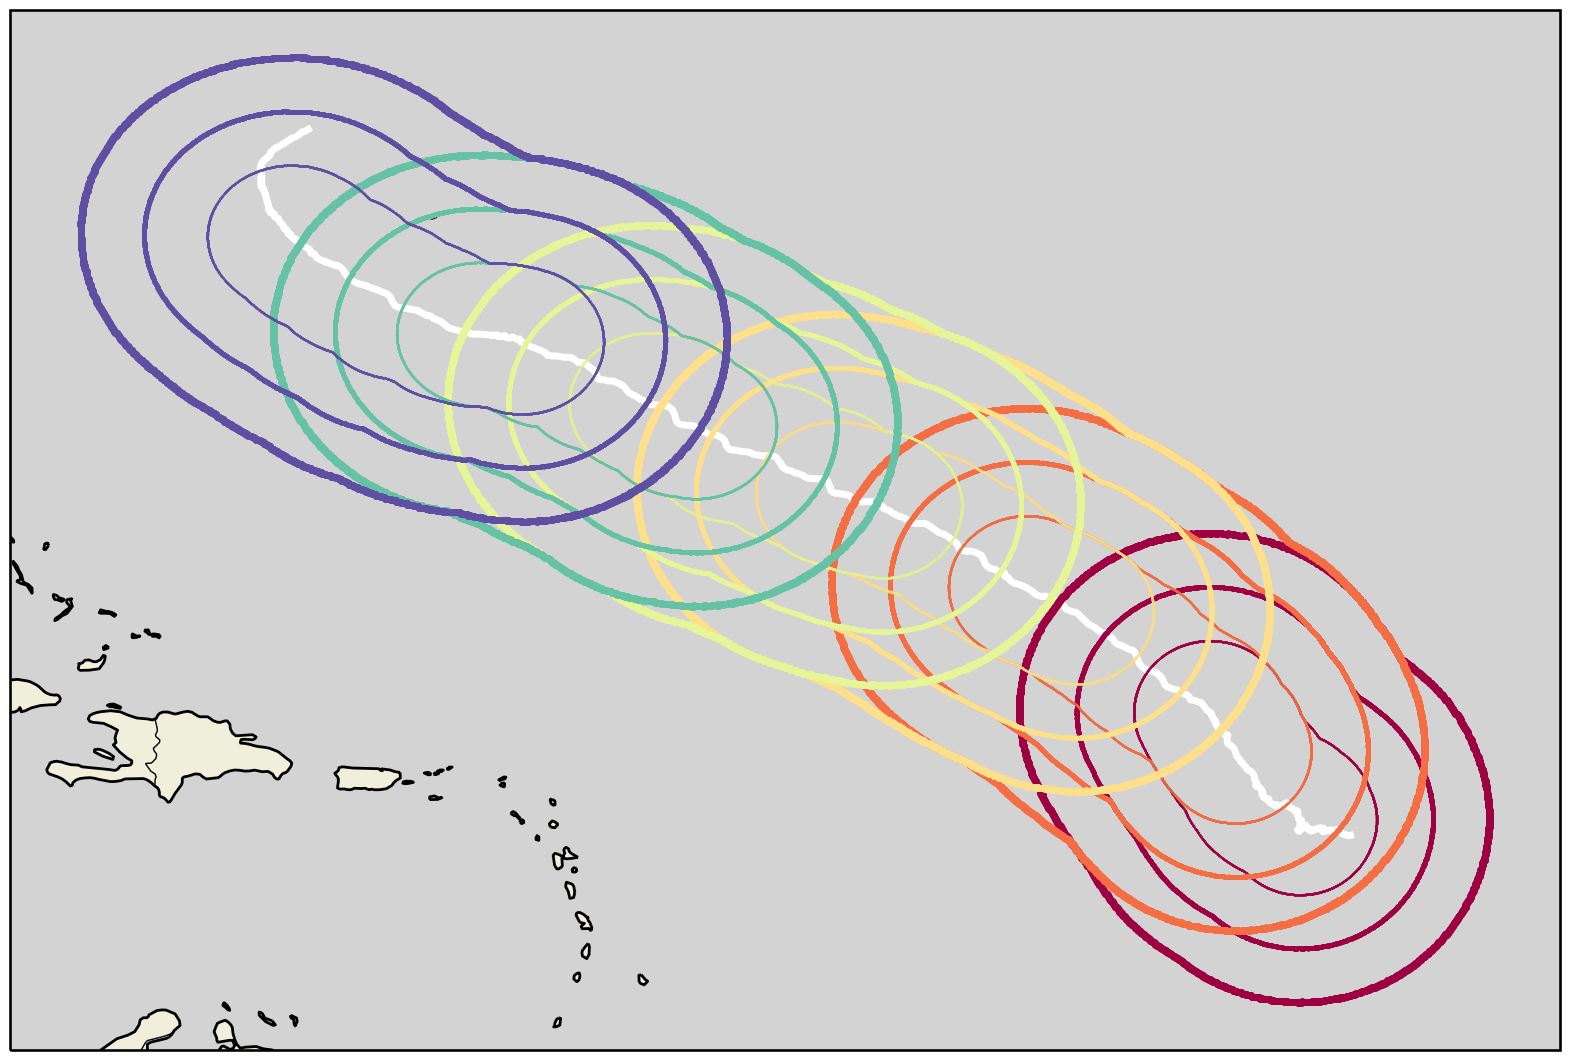

In [14]:
plt.figure( figsize = (20,15))

# this is our map projection
ax = plt.axes(projection = ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale('50m'))
ax.add_feature(cfeature.OCEAN.with_scale('50m'), color = 'lightgray')
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth = 1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth = 2)
#ax.set_extent( (-5,25,42,58))


ax.plot(track.longitude, track.latitude, lw = 5, color = 'white')

grid_files = seg_grids[conf_name].keys()
nfiles = len(grid_files)

colors = list( plt.cm.Spectral(np.linspace(0, 1, nfiles//3)))

i = 0
for n, gname in enumerate( grid_files ):

    grid = seg_grids[conf_name][gname]
    plot_segment( gname, grid, color = colors[i])

    if np.mod(n+1, 3) == 0:
        i += 1

In [15]:
def width_to_desc_mapper( width ):
    if '100km' in width:
        desc = 'narrow'
    elif '200km' in width:
        desc = 'medium'
    elif '300km' in width:
        desc = 'large'
    elif '400km' in width:
        desc = 'x-large'
    return desc    

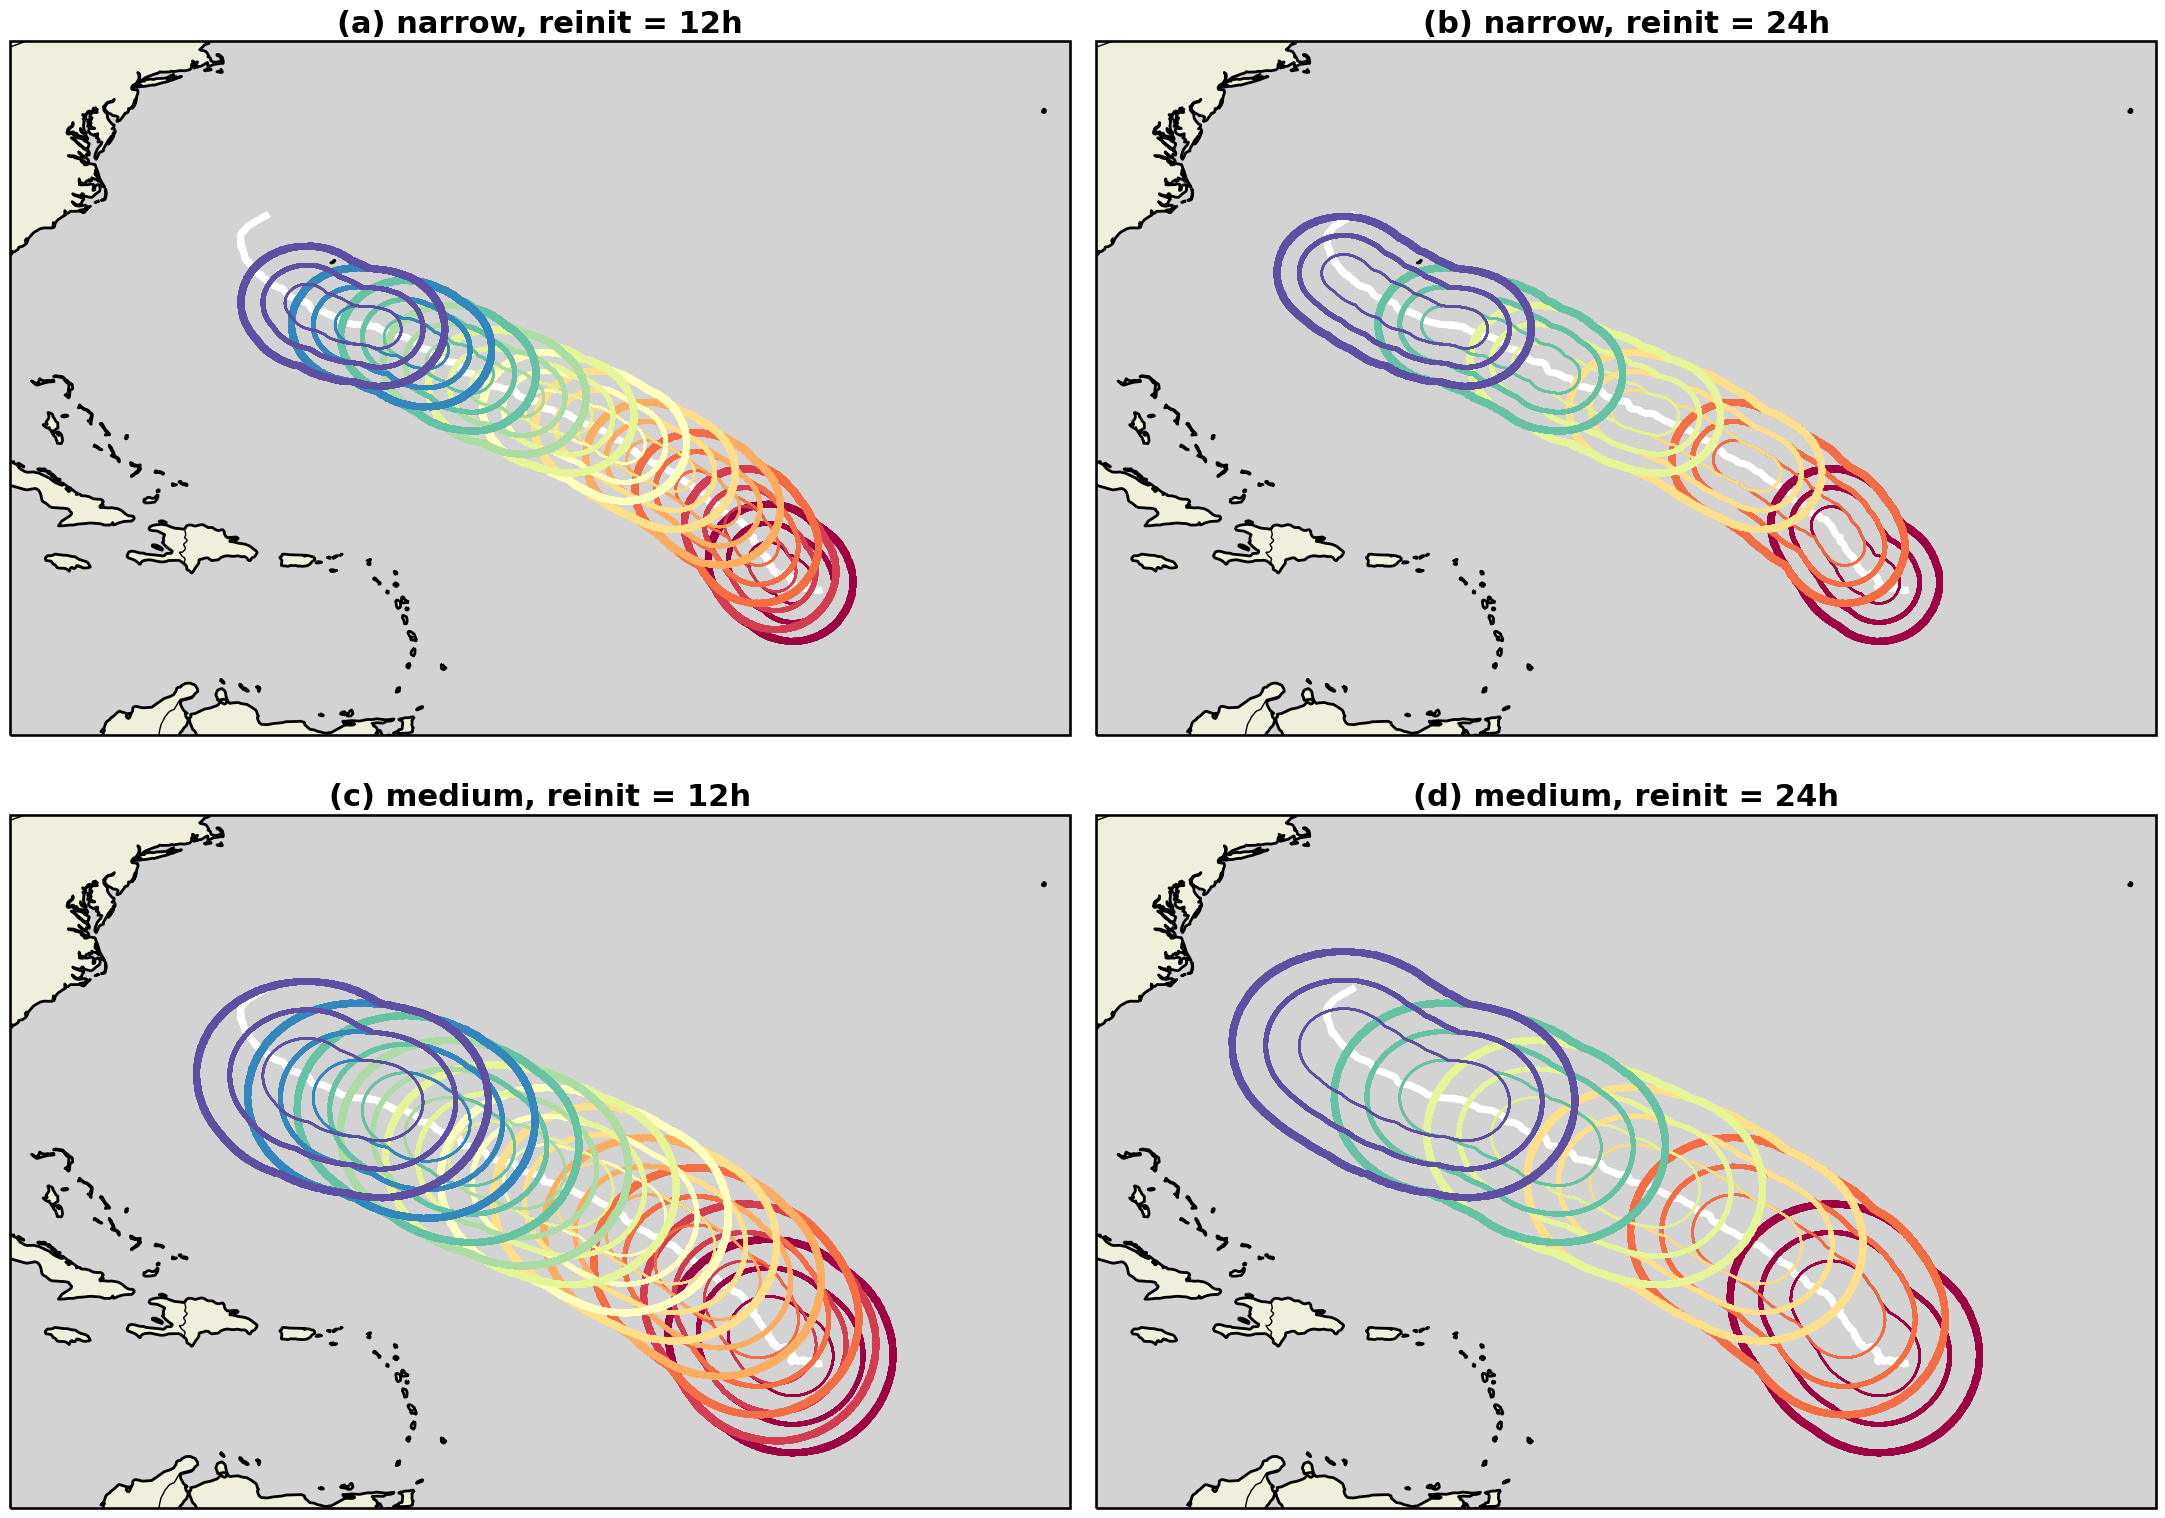

In [16]:
fig, axs = plt.subplots( nrows = 2, ncols = 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(22, 16))
axs = axs.flatten()

abc = string.ascii_lowercase

for ic, conf_name in enumerate( sorted( seg_grids.keys()) ):
    ax = axs[ic]
    plt.sca(ax)
    ax.add_feature(cfeature.LAND.with_scale('50m'))
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), color = 'lightgray')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth = 1)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth = 2)
    ax.set_extent( (-80,-30,10,40))

    ax.plot(track.longitude, track.latitude, lw = 5, color = 'white')

    grid_files = seg_grids[conf_name].keys()
    nfiles = len(grid_files)
    
    colors = list( plt.cm.Spectral(np.linspace(0, 1, nfiles//3)))
    
    i = 0
    for n, gname in enumerate( grid_files ):
    
        grid = seg_grids[conf_name][gname]
        plot_segment( gname, grid, color = colors[i])
    
        if np.mod(n+1, 3) == 0:
            i += 1

    # title
    width_str, reinit_str = conf_name.split('.')[0].split('_')[2:4]

    width_str = width_to_desc_mapper(width_str) #.replace('width', 'width = ')
    reinit_str = reinit_str.replace('reinit', 'reinit = ')
    
    ax.set_title('(%s) %s, %s' % (abc[ic], width_str, reinit_str), fontsize = 22, fontweight = 'bold')
plt.tight_layout()

plt.savefig('../pics/hurricane-centric-domain-overview.png', dpi = 300)